# Multy class classification

## Imports and other helpfull functions

In [1]:
import torch



from torch import nn



import sklearn
from sklearn.datasets import make_gaussian_quantiles
from sklearn.model_selection import train_test_split

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

In [2]:
def plot_decision_boundary(model: torch.nn.Module, X: torch.Tensor, y: torch.Tensor):
    """Plots decision boundaries of model predicting on X in comparison to y.

    Source - https://madewithml.com/courses/foundations/neural-networks/ (with modifications)
    """
    # Put everything to CPU (works better with NumPy + Matplotlib)
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    # Setup prediction boundaries and grid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101), np.linspace(y_min, y_max, 101))

    # Make features
    X_to_pred_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

    # Make predictions
    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_pred_on)

    # Test for multi-class or binary and adjust logits to prediction labels
    if len(torch.unique(y)) > 2:
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)  # mutli-class
    else:
        y_pred = torch.round(torch.sigmoid(y_logits))  # binary

    # Reshape preds and plot
    y_pred = y_pred.reshape(xx.shape).detach().numpy()
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    
    model.to("cuda")

# Plot linear data or training and test and predictions (optional)
def plot_predictions(
    train_data, train_labels, test_data, test_labels, predictions=None
):
    """
  Plots linear training data and test data and compares predictions.
  """
    plt.figure(figsize=(10, 7))

    # Plot training data in blue
    plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

    # Plot test data in green
    plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

    if predictions is not None:
        # Plot the predictions in red (predictions were made on the test data)
        plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

    # Show the legend
    plt.legend(prop={"size": 14})



In [3]:
def accuracy(y_real, y_pred):
    
    correct = torch.eq(y_real, y_pred).sum().item()
    acc = (correct/len(y_pred)) * 100

    return acc

## setting parameters

In [4]:
NUM_CLASSES = 8
NUM_FEATURES = 2

#10

SEED = 80




In [5]:
X_blob, y_blob = make_gaussian_quantiles(n_samples = 2000, n_features = NUM_FEATURES, n_classes = NUM_CLASSES, random_state = SEED)

In [6]:
X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)

In [7]:
X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob, y_blob, test_size = 0.2, random_state = SEED)

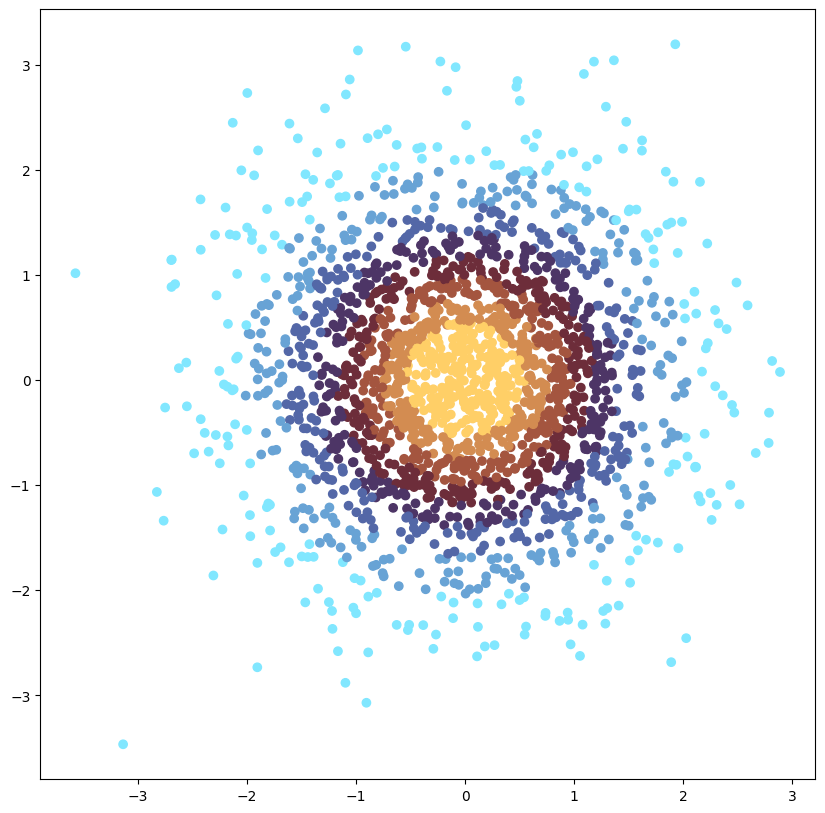

In [8]:
plt.figure(figsize=(10, 10))

plt.scatter(X_blob[:, 0], X_blob[:, 1], c = y_blob, cmap = plt.cm.managua)

## Model

In [9]:
device = "cuda" if torch.cuda.is_available() else "cpu"



device

'cuda'

In [10]:
class MultyClassModel(nn.Module):
    def __init__(self, inputs, outputs, hidden_units = 256):
        
        super().__init__()
        
        self.linear_layer_stack = nn.Sequential(
            nn.Linear(in_features = inputs, out_features = hidden_units),
            nn.Sigmoid(),
            nn.Linear(in_features = hidden_units, out_features = hidden_units),
            nn.Sigmoid(),
            nn.Linear(in_features = hidden_units, out_features = outputs)
        )

    def forward(self, x):
        return self.linear_layer_stack(x)

In [11]:
torch.unique(y_blob)

tensor([0, 1, 2, 3, 4, 5, 6, 7])

In [12]:
model = MultyClassModel(inputs = 2, outputs = 8, hidden_units = 1024).to(device)

model

MultyClassModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=1024, bias=True)
    (1): Sigmoid()
    (2): Linear(in_features=1024, out_features=1024, bias=True)
    (3): Sigmoid()
    (4): Linear(in_features=1024, out_features=8, bias=True)
  )
)

In [13]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(params = model.parameters(), lr = 1
                            
                            
                           )

In [14]:
model.eval()

with torch.inference_mode():
    y_logits = model(X_blob_test.to(device))

y_logits[:5]

tensor([[-0.3318, -0.0977, -0.5078,  0.1460,  0.2268,  0.0273,  0.0357, -0.1810],
        [-0.3299, -0.0996, -0.5123,  0.1672,  0.2630,  0.0443,  0.0305, -0.1979],
        [-0.3315, -0.0993, -0.5099,  0.1564,  0.2432,  0.0338,  0.0361, -0.1902],
        [-0.3302, -0.0999, -0.5124,  0.1673,  0.2626,  0.0434,  0.0317, -0.1983],
        [-0.3317, -0.1021, -0.5142,  0.1760,  0.2755,  0.0464,  0.0339, -0.2065]],
       device='cuda:0')

In [15]:
y_preds_probs = torch.softmax(y_logits, dim = 1
                              
                             )

y_preds_probs[:5]

tensor([[0.0952, 0.1203, 0.0798, 0.1535, 0.1665, 0.1364, 0.1375, 0.1107],
        [0.0946, 0.1191, 0.0788, 0.1555, 0.1711, 0.1375, 0.1356, 0.1079],
        [0.0949, 0.1197, 0.0794, 0.1545, 0.1685, 0.1367, 0.1370, 0.1093],
        [0.0946, 0.1190, 0.0788, 0.1555, 0.1710, 0.1374, 0.1358, 0.1079],
        [0.0941, 0.1184, 0.0784, 0.1564, 0.1728, 0.1374, 0.1357, 0.1067]],
       device='cuda:0')

In [16]:
y_preds = torch.argmax(y_preds_probs, dim = 1)

y_preds[:5]

tensor([4, 4, 4, 4, 4], device='cuda:0')

In [17]:
y_blob_train[:5]

tensor([4, 7, 3, 3, 7])

## training

In [19]:
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)



epoches = 50000

X_blob_train, y_blob_train = X_blob_train.to(device), y_blob_train.to(device)

X_blob_test, y_blob_test = X_blob_test.to(device), y_blob_test.to(device)


for epoch in range(epoches):
    
    model.train()
    

    y_logits = model(X_blob_train)
    y_pred = torch.softmax(y_logits, dim = 1).argmax(dim = 1)
    

    loss = loss_fn(y_logits, y_blob_train)
    acc = accuracy(y_real = y_blob_train, y_pred = y_pred)


    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    

    if epoch % 10000 == 0:
        
        
        model.eval()
        
        with torch.inference_mode():
            
            test_logits = model(X_blob_test.to(device))
            test_preds = torch.softmax(test_logits, dim = 1).argmax(dim = 1)

            test_loss = loss_fn(test_logits, y_blob_test)
            test_acc = accuracy(y_real = y_blob_test, y_pred = test_preds)



        
        
        print(f"Epoch: {epoch}  |  Loss: {loss:.4f}  |  Acc: {acc:.2f}%  ||  Test loss: {test_loss:.4f}  |  Test acc: {test_acc:.2f}%")

Epoch: 0  |  Loss: 0.0270  |  Acc: 99.38%  ||  Test loss: 0.1754  |  Test acc: 92.25%
Epoch: 10000  |  Loss: 0.0180  |  Acc: 99.50%  ||  Test loss: 0.1793  |  Test acc: 93.00%
Epoch: 20000  |  Loss: 0.0104  |  Acc: 100.00%  ||  Test loss: 0.1701  |  Test acc: 94.00%
Epoch: 30000  |  Loss: 0.0073  |  Acc: 100.00%  ||  Test loss: 0.1706  |  Test acc: 94.00%
Epoch: 40000  |  Loss: 0.0052  |  Acc: 100.00%  ||  Test loss: 0.1683  |  Test acc: 94.25%


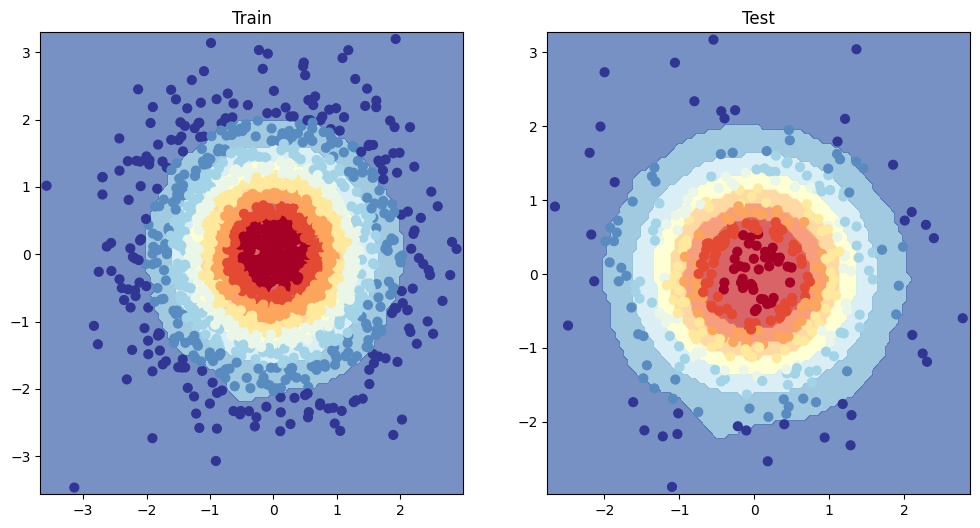

In [20]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_blob_train, y_blob_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_blob_test, y_blob_test)

In [1]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X, y)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_blob_test, y_blob_test)

NameError: name 'plt' is not defined